In [1]:
#COMPLETE KNN MACHINE LEARNING PIPLINE#

# 1 IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
       accuracy_score,
       classification_report,
       confusion_matrix,
       ConfusionMatrixDisplay
)

In [4]:
#Load The data

df = pd.read_csv(r"C:\Users\thula\Downloads\diabetess.csv")

In [5]:
print(df.head())
print('shape of the dataset :' , df.shape)
print('Missing Values : ', df.isnull().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
shape of the dataset : (768, 9)
Missing Values :  Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome      

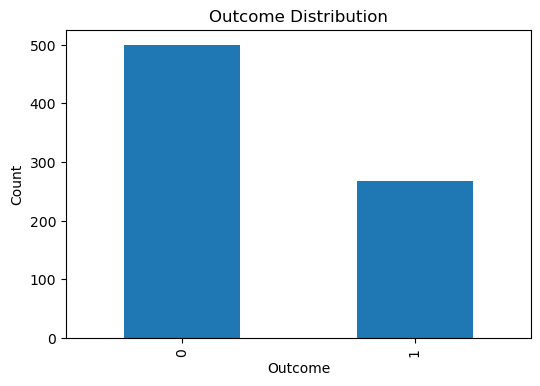

In [6]:
#EDA Visual
plt.figure(figsize=(6,4))
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'BMI')

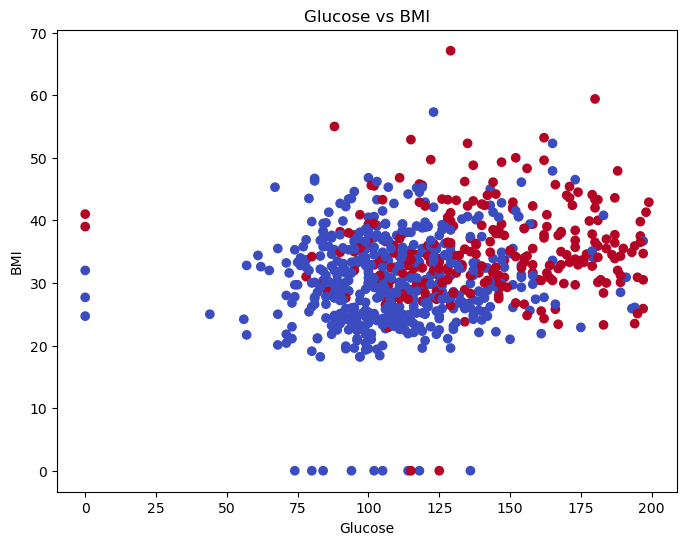

In [7]:
# Glucose vs BMI
plt.figure(figsize=(8,6))
plt.scatter(df['Glucose'], df['BMI'], c=df['Outcome'], cmap='coolwarm')
plt.title('Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')

In [8]:
#Split The Data
x = df.drop('Outcome', axis=1)
y = df['Outcome']

In [9]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [10]:
#Feature Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
#Create Knn model
knn = KNeighborsClassifier(n_neighbors=10)

In [12]:
#Train Model
knn.fit(X_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
#PREDICTION ON TEST DATA

y_pred =knn.predict(X_test)
print('Prediction:', y_pred)

Prediction: [0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1
 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


In [14]:
#Model Evaluvation

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.6883116883116883
              precision    recall  f1-score   support

           0       0.73      0.81      0.77        99
           1       0.58      0.47      0.52        55

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.64       154
weighted avg       0.68      0.69      0.68       154



In [15]:
#Confusion metrics
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[80 19]
 [29 26]]


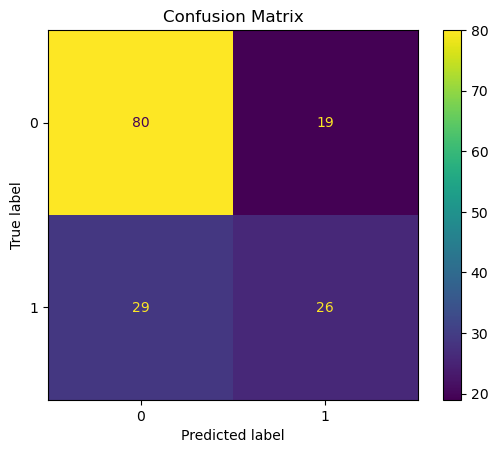

In [16]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title('Confusion Matrix')
plt.show()

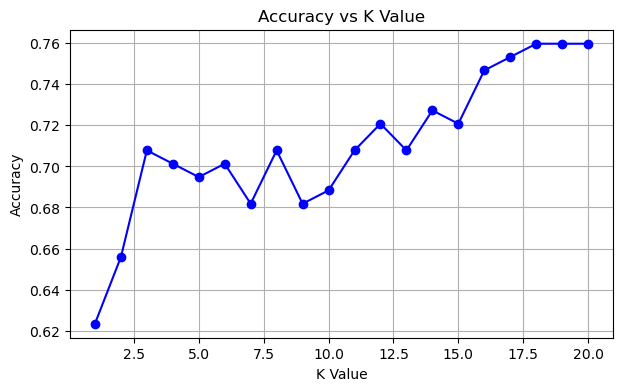

In [17]:
#Find best K Value
k_values = list(range(1, 21))
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    prediction = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, prediction))

plt.figure(figsize=(7,4))
plt.plot(
    k_values,
    accuracy_scores,
    marker='o',
    linestyle='-',
    color='b'
)
plt.title('Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


In [18]:
#User input Prediction

print('Enter Patient Data')
pregnancies = float(input('Pregnancies : '))
glucose = float(input('Glucose : '))
blood_pressure = float(input('Blood Pressure : '))
skin_thickness = float(input('Skin Thickness : '))
insulin = float(input('Insulin : '))
BMI = float(input('BMI : '))
DiabetesPedigreeFunction = float(input('Diabetes Pedigree Function : '))
Age = float(input('Age : '))
# create the data frame
new_data = pd.DataFrame({
    'Pregnancies' : [pregnancies],
    'Glucose' : [glucose],
    'BloodPressure' : [blood_pressure],
    'SkinThickness' : [skin_thickness],
    'Insulin' : [insulin],
    'BMI' : [BMI],
    'DiabetesPedigreeFunction' : [DiabetesPedigreeFunction],
    'Age' : [Age]
})

# Scaler user input
new_pation_scaled = scaler.transform(new_data)

result1 = knn.predict(new_pation_scaled)
print('Prediction : ', result1)

if result1[0] == 1:
    print('Diabetes Positive')
else:
    print('Diabetes Negative')

Enter Patient Data


Pregnancies :  1
Glucose :  85
Blood Pressure :  66
Skin Thickness :  29
Insulin :  0
BMI :  26.6
Diabetes Pedigree Function :  0.351
Age :  31


Prediction :  [0]
Diabetes Negative


In [23]:
import os

print(os.path.exists("KNNAlgorithm.ipynb"))

True
